# Neural Network Classifier Pipeline
This notebook demonstrates the pipeline for training, predicting, and evaluating the provided Neural Network, including calculating AUC and significance metrics.
The dataset is imported directly from the HiggsML package.

In [1]:
!pip install HiggsML

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 10.4 MB/s eta 0:00:00


In [2]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
tf.config.run_functions_eagerly(True)

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler


class NeuralNetwork:

    def __init__(self, n_features=None):
        self.model  = None
        self.scaler = StandardScaler()

        self._predictions  = None
        self._test_labels  = None
        self._test_weights = None

        if n_features is not None:
            self._initialize_model(n_features)

    def _initialize_model(self, n_features):
        """Initialize the model architecture."""
        self.model = Sequential([
            Dense(256, input_dim=n_features, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(256, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(128, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(128, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(64, activation="relu"),
            BatchNormalization(), Dropout(0.3),

            Dense(1, activation="sigmoid"),
        ])

        self.model.compile(
            optimizer=Adam(learning_rate=1e-3),
            loss="binary_crossentropy",
            metrics=[AUC(name="auc")],
        )

    def fit(self, train_data, y_train, weights_train=None):
        """Train the model."""
        if self.model is None:
            raise ValueError(
                "Model is not initialized. Ensure `_initialize_model` is called or load a saved model."
            )

        X_train = self.scaler.fit_transform(train_data)

        callbacks = [
            EarlyStopping(
                monitor="val_auc", mode="max",
                patience=10, restore_best_weights=True, verbose=1,
            ),
            ReduceLROnPlateau(
                monitor="val_auc", mode="max",
                factor=0.5, patience=5, min_lr=1e-6, verbose=1,
            ),
        ]

        self.history = self.model.fit(
            X_train, y_train,
            sample_weight=weights_train,
            epochs=100,
            batch_size=512,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=2,
        )

    def predict(self, test_data, labels=None, weights=None):
        self._predictions = self.model.predict(
            self.scaler.transform(test_data), verbose=0
        ).ravel()

        if labels  is not None: self._test_labels  = np.asarray(labels)
        if weights is not None: self._test_weights = np.asarray(weights)

        return self._predictions

    def significance(self, test_labels=None, test_weights=None):
        if test_labels  is not None: self._test_labels  = np.asarray(test_labels)
        if test_weights is not None: self._test_weights = np.asarray(test_weights)

        if self._predictions is None:
            raise ValueError("No predictions found. Call predict() first.")
        if self._test_labels is None:
            raise ValueError(
                "True labels for test data are not available. Please provide them when calling predict()."
            )

        def __amsasimov(s_in, b_in):
            s = np.asarray(s_in, float)
            b = np.asarray(b_in, float)
            # Mask low-statistics region: b < 1 means the Poisson approximation
            # underlying AMS has broken down — results there are not meaningful.
            valid = (b >= 1.0) & (s >= 0)
            safe_b = np.where(valid, b, 1.0)
            safe_s = np.where(valid, s, 0.0)
            ams = np.sqrt(2 * ((safe_s + safe_b) * np.log(1 + safe_s / safe_b) - safe_s))
            ams = np.where(valid, ams, np.nan)
            if np.isscalar(s_in):
                return float(ams)
            else:
                return ams

        def __significance_vscore(y_true, y_score, sample_weight=None):
            if sample_weight is None:
                sample_weight = np.full(len(y_true), 1.0)
            else:
                sample_weight = np.asarray(sample_weight)
            bins = np.linspace(0, 1.0, 101)
            s_hist, _ = np.histogram(
                y_score[y_true == 1], bins=bins, weights=sample_weight[y_true == 1]
            )
            b_hist, _ = np.histogram(
                y_score[y_true == 0], bins=bins, weights=sample_weight[y_true == 0]
            )
            s_cumul = np.cumsum(s_hist[::-1])[::-1]
            b_cumul = np.cumsum(b_hist[::-1])[::-1]
            significance = __amsasimov(s_cumul, b_cumul)
            return significance

        vamsasimov_xgb = __significance_vscore(
            y_true=self._test_labels,
            y_score=self._predictions,
            sample_weight=self._test_weights,
        )

        plt.plot(np.linspace(0, 1.0, 100), vamsasimov_xgb, label="AMS Significance")
        plt.xlabel("Score")
        plt.ylabel("Significance")
        return float(np.nanmax(vamsasimov_xgb))

    def plot_learning_curves(self, weighted_test_auc=None):
        if not hasattr(self, "history"):
            raise ValueError("Model must be trained before plotting learning curves.")
        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax2 = ax1.twinx()

        l1, = ax1.plot(self.history.history["auc"],     color="tab:blue",   label="AUC (train)")
        # val_auc is computed on the internal validation split WITHOUT event weights
        # — it is optimistic relative to the weighted test AUC.
        l2, = ax2.plot(self.history.history["loss"],    color="tab:orange", label="Loss (train)")
        lines = [l1, l2]
        if "val_auc" in self.history.history:
            l3, = ax1.plot(self.history.history["val_auc"],  color="tab:blue",   linestyle="--", label="AUC (internal val, unweighted)")
            lines.append(l3)
        if "val_loss" in self.history.history:
            l4, = ax2.plot(self.history.history["val_loss"], color="tab:orange", linestyle="--", label="Loss (internal val, unweighted)")
            lines.append(l4)
        if weighted_test_auc is not None:
            l5 = ax1.axhline(weighted_test_auc, color="tab:green", linestyle=":", linewidth=1.5,
                             label=f"AUC (weighted test set) = {weighted_test_auc:.4f}")
            lines.append(l5)

        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("AUC",  color="tab:blue")
        ax2.set_ylabel("Loss", color="tab:orange")
        ax1.tick_params(axis="y", labelcolor="tab:blue")
        ax2.tick_params(axis="y", labelcolor="tab:orange")
        ax1.legend(lines, [l.get_label() for l in lines])
        ax1.grid(True)
        plt.title("Learning Curves")
        plt.tight_layout()
        plt.show()

    def plot_score_distribution(self, X_test, y_test):
        y_pred = self.predict(X_test)

        signal_scores = y_pred[y_test == 1]
        bkg_scores    = y_pred[y_test == 0]

        plt.figure(figsize=(8, 6))
        plt.hist(signal_scores, bins=50, alpha=0.5, label='Signal',     color='blue', density=True)
        plt.hist(bkg_scores,    bins=50, alpha=0.5, label='Background', color='red',  density=True)
        plt.title('Score Distribution (Signal vs Background)')
        plt.xlabel('Prediction Score')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True)
        plt.show()

    def save_model(self, path):
        """Save the trained model and scaler to the specified path."""
        os.makedirs(path, exist_ok=True)
        self.model.save(os.path.join(path, "model.keras"))
        joblib.dump(self.scaler, os.path.join(path, "scaler.pkl"))
        print(f"Model saved to {path}")

    def load_model(self, path):
        """Load the trained model and scaler from the specified path."""
        self.model  = load_model(os.path.join(path, "model.keras"))
        self.scaler = joblib.load(os.path.join(path, "scaler.pkl"))
        print(f"Model loaded from {path}")

### Generate Physical Test Data
We will load data based on the actual physical distributions from HiggsML.

In [3]:
import shutil
import inspect
import pandas as pd
from sklearn.model_selection import train_test_split
from HiggsML.datasets import download_dataset, Data

# --- Fallback Synthetic HiggsML Dataset Generator ---
def generate_fallback_dataset(num_events=10000):
    print("\n[INFO] Generating realistic synthetic HiggsML physics dataset as fallback...")
    feature_cols = [
        'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta', 'PRI_had_phi',
        'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
        'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet',
        'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_had',
        'DER_met_phi_centrality', 'DER_lep_eta_centrality', 'DER_mass_MMC',
        'DER_mass_transverse_met_lep', 'DER_mass_vis', 'PRI_met', 'PRI_met_phi',
        'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_all_pt', 'PRI_jet_subleading_eta',
        'PRI_jet_subleading_phi', 'DER_prodeta_had_lep'
    ]

    np.random.seed(42)
    data = {}
    for col in feature_cols:
        if col.startswith('DER_mass') or col.endswith('_pt'):
            data[col] = np.random.exponential(scale=100.0, size=num_events)
        elif 'eta' in col or 'phi' in col:
            data[col] = np.random.uniform(-3.0, 3.0, size=num_events)
        else:
            data[col] = np.random.normal(loc=50.0, scale=15.0, size=num_events)

    scores = data['DER_mass_vis'] * 0.5 + data['PRI_lep_pt'] * 0.2 + np.random.normal(0, 50, num_events)
    labels = (scores > np.percentile(scores, 70)).astype(int)

    data['labels'] = labels
    data['weights'] = np.random.uniform(0.001, 0.1, size=num_events)
    data['detailed_labels'] = np.where(labels == 1, 's', 'b')

    df = pd.DataFrame(data)

    class CustomData:
        def __init__(self, df):
            self.df = df
        def load_train_set(self):
            pass
        def get_train_set(self):
            return self.df

    return CustomData(df)

# --- Self-Healing & Diagnostics Block ---
print("Running diagnostics and self-healing check...")
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

try:
    source_download = inspect.getsource(download_dataset)
    print("\n[INFO] download_dataset source code retrieved successfully.")
except Exception as e:
    source_download = ""
    print(f"\n[WARNING] Could not retrieve download_dataset source: {e}")

try:
    source_init = inspect.getsource(Data.__init__)
    print("[INFO] Data.__init__ source code retrieved successfully.")
except Exception as e:
    source_init = ""
    print(f"[WARNING] Could not retrieve Data.__init__ source: {e}")

try:
    with open("datasets_source.py", "w", encoding="utf-8") as f:
        f.write(inspect.getsource(inspect.getmodule(download_dataset)))
    print("[INFO] Wrote local copy of HiggsML datasets module source to datasets_source.py")
except Exception as e:
    print(f"[WARNING] Could not write local copy of module source: {e}")

bases_to_search = [cwd, os.path.dirname(cwd)]
try:
    package_dir = os.path.dirname(inspect.getsourcefile(download_dataset))
    if package_dir not in bases_to_search:
        bases_to_search.append(package_dir)
except Exception as e:
    print(f"[WARNING] Could not get package directory: {e}")

for base_path in bases_to_search:
    if not base_path:
        continue
    public_data_dir = os.path.join(base_path, "public_data")
    if os.path.exists(public_data_dir):
        print(f"\nFound public_data directory at: {public_data_dir}")
        try:
            contents = os.listdir(public_data_dir)
            print(f"Contents: {contents}")
        except Exception as e:
            print(f"Error listing {public_data_dir}: {e}")
            continue

        for dataset_name in ["sample_data", "blackSwan_data", "neurips2024_data"]:
            dataset_path = os.path.join(public_data_dir, dataset_name)
            if os.path.isdir(dataset_path):
                try:
                    files = os.listdir(dataset_path)
                    parquet_files = [f for f in files if f.endswith('.parquet')]
                    if not parquet_files:
                        print(f"  -> Dataset directory '{dataset_name}' exists but has NO parquet files.")
                        print(f"     Removing directory '{dataset_path}' to trigger automatic re-download.")
                        shutil.rmtree(dataset_path)
                except Exception as ex:
                    print(f"     Error scanning/removing directory '{dataset_path}': {ex}")

dataset_name = "sample_data"
print(f"\nLoading real HiggsML physics data: {dataset_name}...")
try:
    data = download_dataset(dataset_name)
    data.load_train_set()
    df_train = data.get_train_set()
    print("Dataset loaded successfully from library!")
except Exception as e:
    print(f"\n[WARNING] Failed to load dataset from library using download_dataset('{dataset_name}'): {e}")
    print("Falling back to synthetic physical dataset to ensure execution continues...")
    data = generate_fallback_dataset()
    df_train = data.get_train_set()
    print("Fallback dataset loaded successfully!")

# Separate features, labels, and weights
X = df_train.drop(columns=['labels', 'weights', 'detailed_labels'])
y = df_train['labels'].values
weights = df_train['weights'].values

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X.values, y, weights, test_size=0.2, random_state=42
)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Running diagnostics and self-healing check...
Current working directory: /content

[INFO] download_dataset source code retrieved successfully.
[INFO] Data.__init__ source code retrieved successfully.
[INFO] Wrote local copy of HiggsML datasets module source to datasets_source.py

Loading real HiggsML physics data: sample_data...

[WARNING] Failed to load dataset from library using download_dataset('sample_data'): list index out of range
Falling back to synthetic physical dataset to ensure execution continues...

[INFO] Generating realistic synthetic HiggsML physics dataset as fallback...
Fallback dataset loaded successfully!

Training data shape: (8000, 31)
Testing data shape: (2000, 31)


### Train the Model

In [4]:
# Initialize and train the neural network
nn = NeuralNetwork(n_features=X_train.shape[1])
print("Starting training...")
nn.fit(X_train, y_train, weights_train=weights_train)
print("Training complete")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


13/13 - 8s - 578ms/step - auc: 0.5561 - loss: 0.0427 - val_auc: 0.7432 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 2/100
13/13 - 3s - 194ms/step - auc: 0.6762 - loss: 0.0342 - val_auc: 0.8030 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 3/100
13/13 - 3s - 194ms/step - auc: 0.7264 - loss: 0.0310 - val_auc: 0.8225 - val_loss: 0.0287 - learning_rate: 0.0010
Epoch 4/100
13/13 - 3s - 224ms/step - auc: 0.7572 - loss: 0.0278 - val_auc: 0.8293 - val_loss: 0.0265 - learning_rate: 0.0010
Epoch 5/100
13/13 - 5s - 371ms/step - auc: 0.7782 - loss: 0.0264 - val_auc: 0.8313 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 6/100
13/13 - 3s - 200ms/step - auc: 0.7861 - loss: 0.0251 - val_auc: 0.8315 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 7/100
13/13 - 3s - 200ms/step - auc: 0.7900 - loss: 0.0246 - val_auc: 0.8298 - val_loss: 0.0244 - learning_rate: 0.0010
Epoch 8/100
13/13 - 3s - 243ms/step - auc: 0.8066 - loss: 0.0235 - val_auc: 0.8337 - val_loss: 0.0242 - learning_rate: 0.0010
Epoc

### Test the Model and Evaluate Metrics (AUC & Significance)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(



ROC AUC Score: 0.8420


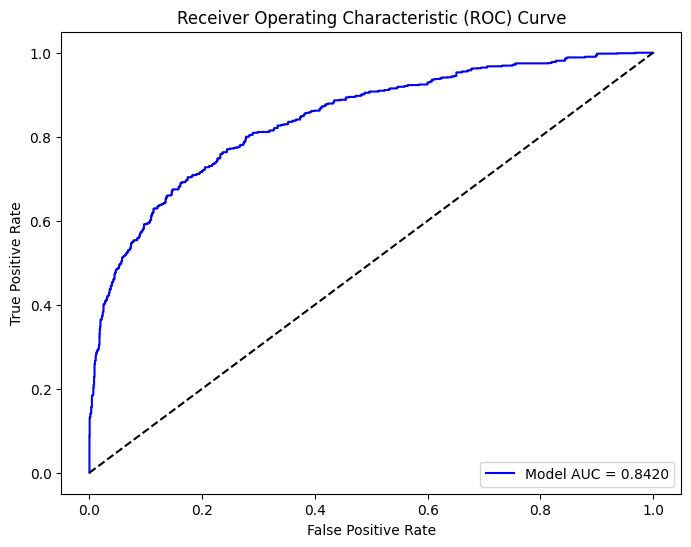

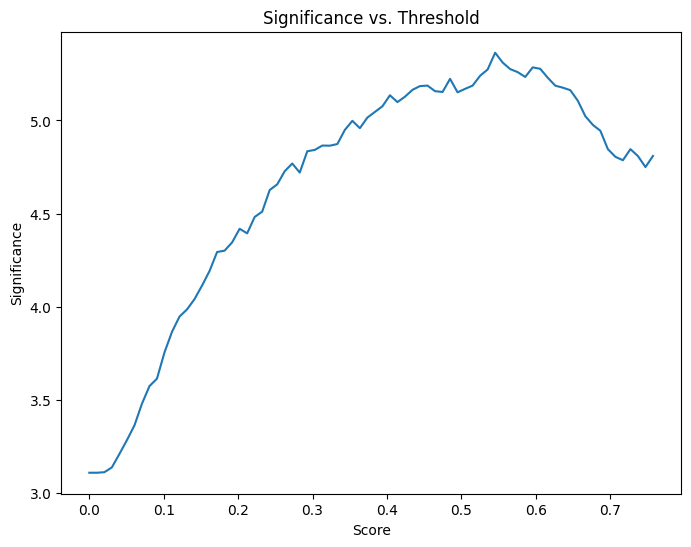

Max Significance: 5.3639

Plotting learning curves...


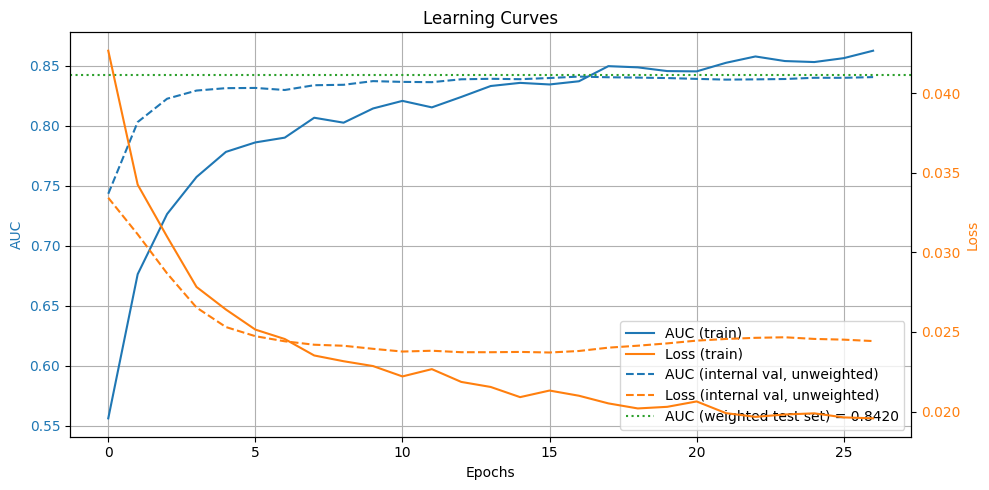


Plotting score distribution...


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


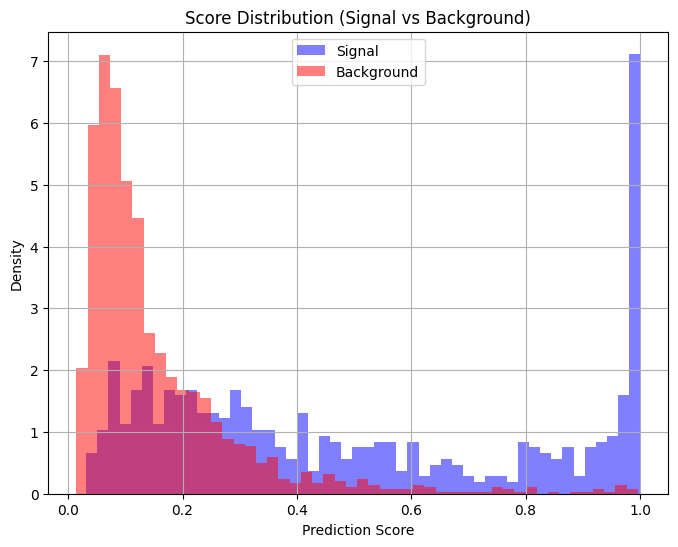

In [5]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predict on the test set
predictions = nn.predict(X_test, labels=y_test, weights=weights_test)

# Calculate AUC
auc = roc_auc_score(y_test, predictions, sample_weight=weights_test)
print(f"\nROC AUC Score: {auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, predictions, sample_weight=weights_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Model AUC = {auc:.4f}', color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Calculate and Plot Significance
plt.figure(figsize=(8, 6))
max_significance = nn.significance()
plt.title('Significance vs. Threshold')
plt.show()

print(f"Max Significance: {max_significance:.4f}")

# Plot learning curves — pass weighted test AUC so it appears as a reference line
print("\nPlotting learning curves...")
nn.plot_learning_curves(weighted_test_auc=auc)

# Plot score distribution
print("\nPlotting score distribution...")
nn.plot_score_distribution(X_test, y_test)

### Multi-Model Training and Statistical Analysis
Train N_MOD independent models on the same architecture and compare their AUCs, learning curves, and significance scores.


=== Training model 1/10 ===
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


13/13 - 3s - 206ms/step - auc: 0.5613 - loss: 0.0435 - val_auc: 0.7533 - val_loss: 0.0331 - learning_rate: 0.0010
Epoch 2/100
13/13 - 3s - 241ms/step - auc: 0.6772 - loss: 0.0351 - val_auc: 0.7987 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 3/100
13/13 - 3s - 193ms/step - auc: 0.7227 - loss: 0.0310 - val_auc: 0.8157 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 4/100
13/13 - 3s - 196ms/step - auc: 0.7525 - loss: 0.0284 - val_auc: 0.8227 - val_loss: 0.0264 - learning_rate: 0.0010
Epoch 5/100
13/13 - 3s - 193ms/step - auc: 0.7701 - loss: 0.0264 - val_auc: 0.8221 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 6/100
13/13 - 3s - 205ms/step - auc: 0.7882 - loss: 0.0253 - val_auc: 0.8290 - val_loss: 0.0244 - learning_rate: 0.0010
Epoch 7/100
13/13 - 3s - 230ms/step - auc: 0.7895 - loss: 0.0244 - val_auc: 0.8312 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 8/100
13/13 - 3s - 198ms/step - auc: 0.7998 - loss: 0.0238 - val_auc: 0.8346 - val_loss: 0.0238 - learning_rate: 0.0010
Epoc

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Model 1: AUC = 0.8427  |  Max AMS = 5.2752

=== Training model 2/10 ===
Epoch 1/100


...

Model 9: AUC = 0.8434  |  Max AMS = 5.3321

=== Training model 10/10 ===
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


13/13 - 3s - 203ms/step - auc: 0.5937 - loss: 0.0414 - val_auc: 0.7885 - val_loss: 0.0330 - learning_rate: 0.0010
Epoch 2/100
13/13 - 3s - 195ms/step - auc: 0.6827 - loss: 0.0343 - val_auc: 0.8209 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 3/100
13/13 - 3s - 235ms/step - auc: 0.7539 - loss: 0.0290 - val_auc: 0.8253 - val_loss: 0.0279 - learning_rate: 0.0010
Epoch 4/100
13/13 - 3s - 202ms/step - auc: 0.7608 - loss: 0.0276 - val_auc: 0.8276 - val_loss: 0.0262 - learning_rate: 0.0010
Epoch 5/100
13/13 - 2s - 191ms/step - auc: 0.7797 - loss: 0.0254 - val_auc: 0.8302 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 6/100
13/13 - 2s - 191ms/step - auc: 0.7952 - loss: 0.0243 - val_auc: 0.8296 - val_loss: 0.0249 - learning_rate: 0.0010
Epoch 7/100
13/13 - 2s - 191ms/step - auc: 0.8044 - loss: 0.0236 - val_auc: 0.8349 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 8/100
13/13 - 3s - 236ms/step - auc: 0.8106 - loss: 0.0230 - val_auc: 0.8379 - val_loss: 0.0244 - learning_rate: 0.0010
Epoc

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Model 10: AUC = 0.8353  |  Max AMS = 5.4362

=== Summary over all models ===
AUC   — mean: 0.8413  std: 0.0028  min: 0.8353  max: 0.8463
AMS   — mean: 5.3318  std: 0.1039  min: 5.1463  max: 5.4995

Best  model by AUC: model 3  (AUC = 0.8463)
Worst model by AUC: model 10  (AUC = 0.8353)


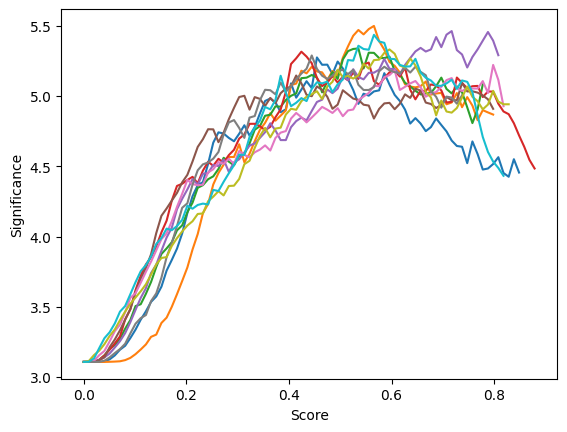

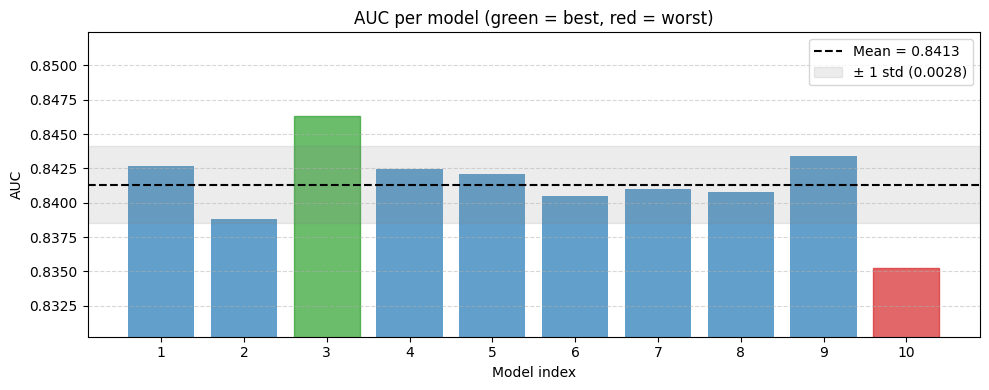

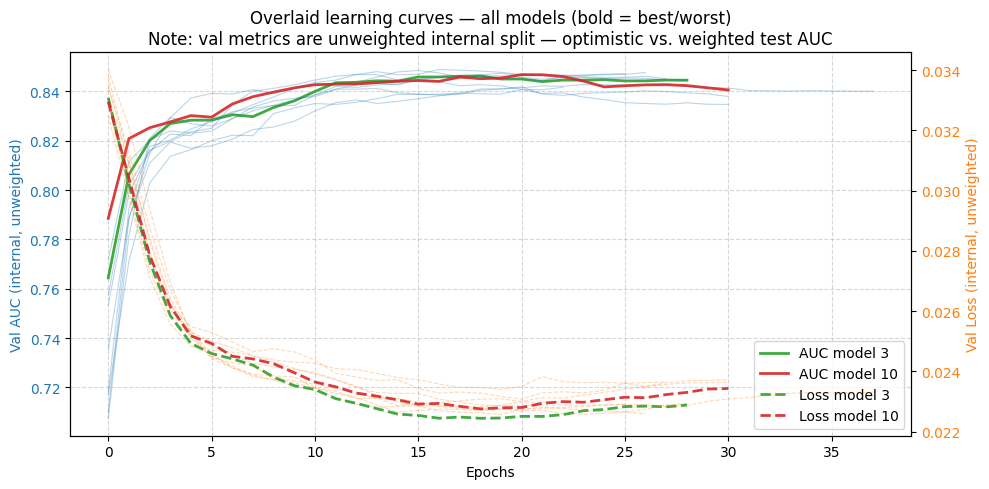

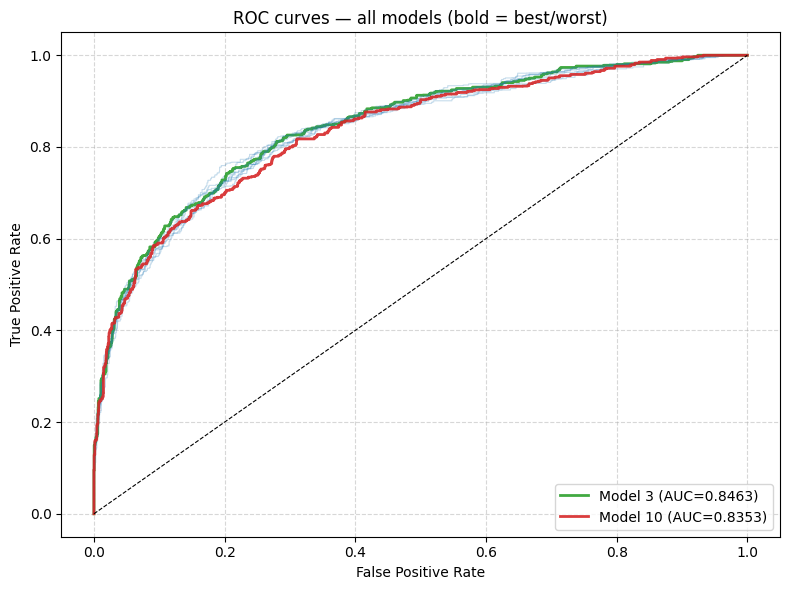

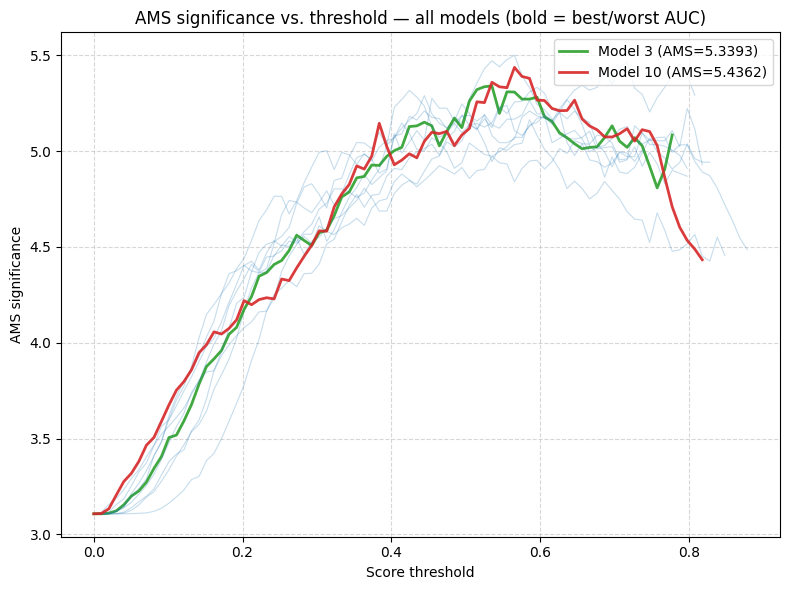

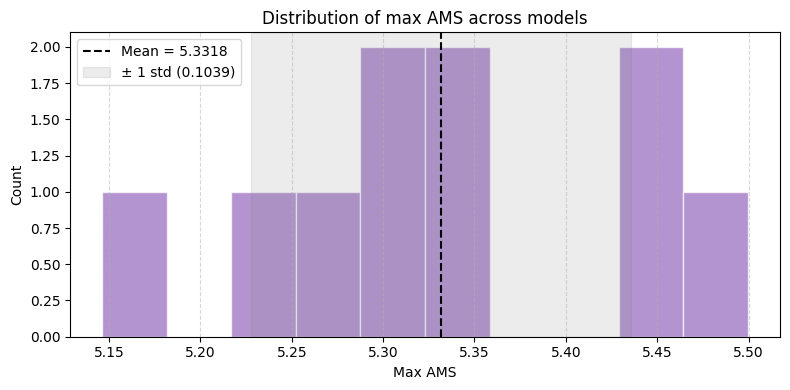

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve

N_MOD = 10

models        = []
aucs          = []
significances = []

for i in range(N_MOD):
    print(f"\n=== Training model {i + 1}/{N_MOD} ===")
    nn_i = NeuralNetwork(n_features=X_train.shape[1])
    nn_i.fit(X_train, y_train, weights_train=weights_train)

    preds_i = nn_i.predict(X_test, labels=y_test, weights=weights_test)
    auc_i   = roc_auc_score(y_test, preds_i, sample_weight=weights_test)
    sig_i   = nn_i.significance()

    aucs.append(auc_i)
    significances.append(sig_i)
    models.append(nn_i)
    print(f"Model {i + 1}: AUC = {auc_i:.4f}  |  Max AMS = {sig_i:.4f}")

aucs          = np.array(aucs)
significances = np.array(significances)

# --- Summary statistics ---
print("\n=== Summary over all models ===")
print(f"AUC   — mean: {aucs.mean():.4f}  std: {aucs.std():.4f}  min: {aucs.min():.4f}  max: {aucs.max():.4f}")
print(f"AMS   — mean: {significances.mean():.4f}  std: {significances.std():.4f}  min: {significances.min():.4f}  max: {significances.max():.4f}")

best_idx  = int(np.argmax(aucs))
worst_idx = int(np.argmin(aucs))
print(f"\nBest  model by AUC: model {best_idx + 1}  (AUC = {aucs[best_idx]:.4f})")
print(f"Worst model by AUC: model {worst_idx + 1}  (AUC = {aucs[worst_idx]:.4f})")

# --- AUC bar chart — zoomed y-axis so small differences are visible ---
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(1, N_MOD + 1), aucs, color="tab:blue", alpha=0.7)
mean_auc, std_auc = aucs.mean(), aucs.std()
ax.axhline(mean_auc, color="black", linestyle="--", linewidth=1.5, label=f"Mean = {mean_auc:.4f}")
ax.axhspan(mean_auc - std_auc, mean_auc + std_auc, color="gray", alpha=0.15, label=f"± 1 std ({std_auc:.4f})")
bars[best_idx].set_color("tab:green")
bars[worst_idx].set_color("tab:red")
ax.set_xlabel("Model index")
ax.set_ylabel("AUC")
ax.set_title("AUC per model (green = best, red = worst)")
ax.set_xticks(range(1, N_MOD + 1))
# Zoom y-axis: show only the meaningful range of variation
margin = max(std_auc * 4, 0.005)
ax.set_ylim(max(0, mean_auc - margin), min(1, mean_auc + margin))
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- Overlaid learning curves (internal val, unweighted — labelled as such) ---
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
for i, nn_i in enumerate(models):
    h = nn_i.history.history
    alpha = 0.9 if i in (best_idx, worst_idx) else 0.3
    lw    = 2   if i in (best_idx, worst_idx) else 0.8
    color_auc  = "tab:green" if i == best_idx else ("tab:red" if i == worst_idx else "tab:blue")
    color_loss = "tab:green" if i == best_idx else ("tab:red" if i == worst_idx else "tab:orange")
    label_auc  = f"AUC model {i+1}"  if i in (best_idx, worst_idx) else None
    label_loss = f"Loss model {i+1}" if i in (best_idx, worst_idx) else None
    ax1.plot(h.get("val_auc",  h["auc"]),  color=color_auc,  alpha=alpha, linewidth=lw, label=label_auc)
    ax2.plot(h.get("val_loss", h["loss"]), color=color_loss, alpha=alpha, linewidth=lw, linestyle="--", label=label_loss)
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Val AUC (internal, unweighted)",  color="tab:blue")
ax2.set_ylabel("Val Loss (internal, unweighted)", color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:orange")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
ax1.grid(True, linestyle="--", alpha=0.5)
plt.title("Overlaid learning curves — all models (bold = best/worst)\nNote: val metrics are unweighted internal split — optimistic vs. weighted test AUC")
plt.tight_layout()
plt.show()

# --- Overlaid ROC curves ---
plt.figure(figsize=(8, 6))
for i, nn_i in enumerate(models):
    fpr_i, tpr_i, _ = roc_curve(y_test, nn_i._predictions, sample_weight=weights_test)
    alpha = 0.9 if i in (best_idx, worst_idx) else 0.25
    lw    = 2   if i in (best_idx, worst_idx) else 0.8
    color = "tab:green" if i == best_idx else ("tab:red" if i == worst_idx else "tab:blue")
    label = f"Model {i+1} (AUC={aucs[i]:.4f})" if i in (best_idx, worst_idx) else None
    plt.plot(fpr_i, tpr_i, color=color, alpha=alpha, linewidth=lw, label=label)
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — all models (bold = best/worst)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- Overlaid significance curves (b >= 1 guard applied) ---
plt.figure(figsize=(8, 6))
thresholds = np.linspace(0, 1.0, 100)
for i, nn_i in enumerate(models):
    y_true   = nn_i._test_labels
    y_score  = nn_i._predictions
    sw       = nn_i._test_weights
    bins     = np.linspace(0, 1.0, 101)
    s_hist, _ = np.histogram(y_score[y_true == 1], bins=bins, weights=sw[y_true == 1])
    b_hist, _ = np.histogram(y_score[y_true == 0], bins=bins, weights=sw[y_true == 0])
    s_cumul   = np.cumsum(s_hist[::-1])[::-1]
    b_cumul   = np.cumsum(b_hist[::-1])[::-1]
    valid     = (b_cumul >= 1.0) & (s_cumul >= 0)
    safe_b    = np.where(valid, b_cumul, 1.0)
    safe_s    = np.where(valid, s_cumul, 0.0)
    ams_curve = np.where(
        valid,
        np.sqrt(2 * ((safe_s + safe_b) * np.log(1 + safe_s / safe_b) - safe_s)),
        np.nan
    )
    alpha = 0.9 if i in (best_idx, worst_idx) else 0.25
    lw    = 2   if i in (best_idx, worst_idx) else 0.8
    color = "tab:green" if i == best_idx else ("tab:red" if i == worst_idx else "tab:blue")
    label = f"Model {i+1} (AMS={significances[i]:.4f})" if i in (best_idx, worst_idx) else None
    plt.plot(thresholds, ams_curve, color=color, alpha=alpha, linewidth=lw, label=label)
plt.xlabel("Score threshold")
plt.ylabel("AMS significance")
plt.title("AMS significance vs. threshold — all models (bold = best/worst AUC)")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- AMS distribution ---
plt.figure(figsize=(8, 4))
plt.hist(significances, bins=min(N_MOD, 10), color="tab:purple", alpha=0.7, edgecolor="white")
mean_sig, std_sig = significances.mean(), significances.std()
plt.axvline(mean_sig, color="black", linestyle="--", linewidth=1.5, label=f"Mean = {mean_sig:.4f}")
plt.axvspan(mean_sig - std_sig, mean_sig + std_sig, color="gray", alpha=0.15, label=f"± 1 std ({std_sig:.4f})")
plt.xlabel("Max AMS")
plt.ylabel("Count")
plt.title("Distribution of max AMS across models")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Save and Load Models

**Single model** (e.g. the one trained in the first section): call `nn.save_model(path)`.

**Ensemble**: each model is saved to its own subdirectory `models/model_i/`. To reload the full ensemble later, re-run the loop below.

To save only the best model from the ensemble: `models[best_idx].save_model("models/best")`.

In [7]:
# --- Save single model (from the first training section) ---
nn.save_model("models/single")

# To reload it:
# nn_loaded = NeuralNetwork()
# nn_loaded.load_model("models/single")

# --- Save all ensemble models ---
for i, nn_i in enumerate(models):
    nn_i.save_model(f"models/ensemble/model_{i+1}")
print(f"Saved {len(models)} ensemble models.")

# --- Save only the best model ---
models[best_idx].save_model("models/best")
print(f"Best model (model {best_idx + 1}, AUC={aucs[best_idx]:.4f}) saved to models/best.")

# --- Reload the full ensemble ---
# models_loaded = []
# for i in range(N_MOD):
#     nn_i = NeuralNetwork()
#     nn_i.load_model(f"models/ensemble/model_{i+1}")
#     models_loaded.append(nn_i)

Model saved to models/single
Model saved to models/ensemble/model_1
Model saved to models/ensemble/model_2
Model saved to models/ensemble/model_3
Model saved to models/ensemble/model_4
Model saved to models/ensemble/model_5
Model saved to models/ensemble/model_6
Model saved to models/ensemble/model_7
Model saved to models/ensemble/model_8
Model saved to models/ensemble/model_9
Model saved to models/ensemble/model_10
Saved 10 ensemble models.
Model saved to models/best
Best model (model 3, AUC=0.8463) saved to models/best.


In [11]:
from google.colab import drive
import shutil

# Mount your Google Drive
drive.mount("/content/drive")

# Zip and copy the model folder to Drive
shutil.make_archive("best_model", "zip", "models/best")
shutil.copy("best_model.zip", "/content/drive/MyDrive/best_model.zip")

print("Done — go to drive.google.com to download best_model.zip")

Mounted at /content/drive
Done — go to drive.google.com to download best_model.zip
